# Inventory Tool Walkthrough

This notebook introduces the inventory tool from scratch.
It is written for someone who has not seen the code before and wants to understand how the system works.

The notebook uses its own demo database so you can run every cell safely without changing your main inventory data.

## 1. Core Idea

This tool is built around a simple pattern:

1. Create an inventory.
2. Make that inventory the active working context.
3. Start with a few default fields: `name`, `quantity`, `price`, `location`, and `notes`.
4. Add any custom fields that your inventory needs.
5. Add items using those fields.

This makes the tool flexible enough for office supplies, warehouse stock, personal collections, equipment tracking, and many other use cases.

## 2. Set Up A Clean Demo Environment

This cell does five things:

1. Finds the project root.
2. Loads the code from the local `src/` directory.
3. Clears any cached project modules so notebook reruns pick up the latest code.
4. Resets the demo database so the walkthrough always starts from a known clean state.
5. Defines a notebook variable called `ACTIVE_INVENTORY` to mirror the CLI idea of working inside one inventory context.

In [73]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "inventory_tool").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) in sys.path:
    sys.path.remove(str(SRC_PATH))
sys.path.insert(0, str(SRC_PATH))

for module_name in list(sys.modules):
    if module_name == "inventory_tool" or module_name.startswith("inventory_tool."):
        del sys.modules[module_name]

from inventory_tool.db import initialize_database, connect
from inventory_tool.models import InventoryDefinition, InventoryField, InventoryItem
from inventory_tool.service import add_field, add_item, create_inventory, list_fields, list_inventories, list_items, summary

DEMO_DB_PATH = PROJECT_ROOT / "notebooks" / "demo_inventory.db"
if DEMO_DB_PATH.exists():
    DEMO_DB_PATH.unlink()
initialize_database(DEMO_DB_PATH)

ACTIVE_INVENTORY = "office_supplies"

def add_item_to_active_inventory(values: dict[str, str]) -> int:
    return add_item(InventoryItem(inventory_name=ACTIVE_INVENTORY, values=values), DEMO_DB_PATH)

def list_active_inventory_fields():
    return list_fields(ACTIVE_INVENTORY, DEMO_DB_PATH)

def list_active_inventory_items():
    return list_items(DEMO_DB_PATH, inventory_name=ACTIVE_INVENTORY)

def summarize_active_inventory():
    return summary(DEMO_DB_PATH, inventory_name=ACTIVE_INVENTORY)

print(f"Project root: {PROJECT_ROOT}")
print(f"Demo database: {DEMO_DB_PATH}")
print(f"Active inventory in this notebook: {ACTIVE_INVENTORY}")

Project root: /home/boydm9/inventory_tool2
Demo database: /home/boydm9/inventory_tool2/notebooks/demo_inventory.db
Active inventory in this notebook: office_supplies


## 3. What A Typical User Does In The CLI

Before working through the Python examples below, it helps to see the normal terminal workflow.
These are representative commands a user would run on the command line.

In [74]:
example_commands = [
    "python3 main.py create-inventory --name office_supplies --description 'General office supply inventory'",
    "python3 main.py current-inventory",
    "python3 main.py list-fields",
    "python3 main.py add-field --field-name sku --field-type string",
    "python3 main.py add-field --field-name supplier --field-type string",
    "python3 main.py add-item --value name='Printer Paper' --value quantity=12 --value price=6.99 --value sku=PAPER-001",
    "python3 main.py list-items",
    "python3 main.py summary",
]

example_commands

["python3 main.py create-inventory --name office_supplies --description 'General office supply inventory'",
 'python3 main.py current-inventory',
 'python3 main.py list-fields',
 'python3 main.py add-field --field-name sku --field-type string',
 'python3 main.py add-field --field-name supplier --field-type string',
 "python3 main.py add-item --value name='Printer Paper' --value quantity=12 --value price=6.99 --value sku=PAPER-001",
 'python3 main.py list-items',
 'python3 main.py summary']

## 4. Create A Demo Inventory

This creates a single inventory named `office_supplies`.
An inventory is the top-level container that holds both the field definitions and the items for one use case.
In the CLI, creating an inventory also makes it the active inventory automatically.
In this notebook, the active inventory is represented by the `ACTIVE_INVENTORY` variable.

In [75]:
create_inventory(
    InventoryDefinition(
        inventory_name=ACTIVE_INVENTORY,
        description="Demo inventory for general office supplies",
    ),
    DEMO_DB_PATH,
)

list_inventories(DEMO_DB_PATH)

[{'id': 1,
  'inventory_name': 'office_supplies',
  'description': 'Demo inventory for general office supplies',
  'created_at': '2026-03-27 03:16:19',
  'field_count': 5}]

## 5. Inspect The Default Fields

Every new inventory begins with generic fields that work in many situations.
This gives users a useful starting point even before they add any custom fields.

In [76]:
list_active_inventory_fields()

[{'id': 1,
  'field_name': 'name',
  'field_type': 'string',
  'required': 1,
  'default_value': None,
  'display_order': 1},
 {'id': 2,
  'field_name': 'quantity',
  'field_type': 'integer',
  'required': 1,
  'default_value': '1',
  'display_order': 2},
 {'id': 3,
  'field_name': 'price',
  'field_type': 'number',
  'required': 0,
  'default_value': None,
  'display_order': 3},
 {'id': 4,
  'field_name': 'location',
  'field_type': 'string',
  'required': 0,
  'default_value': None,
  'display_order': 4},
 {'id': 5,
  'field_name': 'notes',
  'field_type': 'string',
  'required': 0,
  'default_value': None,
  'display_order': 5}]

## 6. Add Custom Fields

Most real inventories need more than the default fields.
In this example, the inventory is for office supplies, so we add:

- `sku`
- `supplier`
- `reorder_level`

These are just examples. In a real deployment, users could define whatever fields make sense for their own inventory.

In [77]:
add_field(ACTIVE_INVENTORY, InventoryField(field_name="sku", field_type="string"), DEMO_DB_PATH)
add_field(ACTIVE_INVENTORY, InventoryField(field_name="supplier", field_type="string"), DEMO_DB_PATH)
add_field(ACTIVE_INVENTORY, InventoryField(field_name="reorder_level", field_type="integer", default_value="0"), DEMO_DB_PATH)

list_active_inventory_fields()

[{'id': 1,
  'field_name': 'name',
  'field_type': 'string',
  'required': 1,
  'default_value': None,
  'display_order': 1},
 {'id': 2,
  'field_name': 'quantity',
  'field_type': 'integer',
  'required': 1,
  'default_value': '1',
  'display_order': 2},
 {'id': 3,
  'field_name': 'price',
  'field_type': 'number',
  'required': 0,
  'default_value': None,
  'display_order': 3},
 {'id': 4,
  'field_name': 'location',
  'field_type': 'string',
  'required': 0,
  'default_value': None,
  'display_order': 4},
 {'id': 5,
  'field_name': 'notes',
  'field_type': 'string',
  'required': 0,
  'default_value': None,
  'display_order': 5},
 {'id': 6,
  'field_name': 'sku',
  'field_type': 'string',
  'required': 0,
  'default_value': None,
  'display_order': 6},
 {'id': 7,
  'field_name': 'supplier',
  'field_type': 'string',
  'required': 0,
  'default_value': None,
  'display_order': 7},
 {'id': 8,
  'field_name': 'reorder_level',
  'field_type': 'integer',
  'required': 0,
  'default_value'

## 7. Add Example Items

Now that the inventory structure is ready, we can add items.
In this notebook, item entry happens inside the active inventory context, so the inventory itself is not part of each example record.
Each example below only contains the field values for one item.
If the same item is added again with identical field values, the tool merges it by increasing the stored quantity instead of creating a duplicate row.

In [78]:
demo_item_values = [
    {
            "name": "Printer Paper",
            "quantity": "12",
            "price": "6.99",
            "location": "Shelf A",
            "notes": "Letter size",
            "sku": "PAPER-001",
            "supplier": "Staples",
            "reorder_level": "4",
    },
    {
            "name": "Blue Pens",
            "quantity": "48",
            "price": "1.25",
            "location": "Drawer 2",
            "notes": "Fine point",
            "sku": "PEN-101",
            "supplier": "Office Depot",
            "reorder_level": "12",
    },
    {
            "name": "Shipping Labels",
            "quantity": "20",
            "price": "14.50",
            "location": "Cabinet B",
            "notes": "Thermal printer compatible",
            "sku": "LBL-220",
            "supplier": "Uline",
            "reorder_level": "5",
    },
]

created_items = []
for values in demo_item_values:
    add_item_to_active_inventory(values)
    created_items.append({"name": values["name"], "quantity": int(values["quantity"])})

created_items

[{'name': 'Printer Paper', 'quantity': 12},
 {'name': 'Blue Pens', 'quantity': 48},
 {'name': 'Shipping Labels', 'quantity': 20}]

## 8. Review The Saved Items

The service layer returns a normalized view of each item.
It treats `name`, `quantity`, and `price` as especially important default fields because they are useful for summaries and reporting.

In [79]:
rows = list_active_inventory_items()
rows

[{'id': 1,
  'inventory_name': 'office_supplies',
  'values': {'name': 'Printer Paper',
   'quantity': '12',
   'price': '6.99',
   'location': 'Shelf A',
   'notes': 'Letter size',
   'sku': 'PAPER-001',
   'supplier': 'Staples',
   'reorder_level': '4'},
  'name': 'Printer Paper',
  'quantity': 12,
  'price': 6.99,
  'market_value': 83.88},
 {'id': 2,
  'inventory_name': 'office_supplies',
  'values': {'name': 'Blue Pens',
   'quantity': '48',
   'price': '1.25',
   'location': 'Drawer 2',
   'notes': 'Fine point',
   'sku': 'PEN-101',
   'supplier': 'Office Depot',
   'reorder_level': '12'},
  'name': 'Blue Pens',
  'quantity': 48,
  'price': 1.25,
  'market_value': 60.0},
 {'id': 3,
  'inventory_name': 'office_supplies',
  'values': {'name': 'Shipping Labels',
   'quantity': '20',
   'price': '14.50',
   'location': 'Cabinet B',
   'notes': 'Thermal printer compatible',
   'sku': 'LBL-220',
   'supplier': 'Uline',
   'reorder_level': '5'},
  'name': 'Shipping Labels',
  'quantity':

## 9. Load The Inventory Into A DataFrame

This turns the normalized item output into a pandas DataFrame for filtering, sorting, and analysis.

In [80]:
import pandas as pd

inventory = pd.DataFrame([
    {
        "id": row["id"],
        "inventory_name": row["inventory_name"],
        **row["values"],
        "market_value": row["market_value"],
    }
    for row in rows
])
inventory

,id,inventory_name,name,quantity,price,location,notes,sku,supplier,reorder_level,market_value
0,1,office_supplies,Printer Paper,12,6.99,Shelf A,Letter size,PAPER-001,Staples,4,83.88
1,2,office_supplies,Blue Pens,48,1.25,Drawer 2,Fine point,PEN-101,Office Depot,12,60.00
2,3,office_supplies,Shipping Labels,20,14.50,Cabinet B,Thermal printer compatible,LBL-220,Uline,5,290.00


## 10. Summarize The Inventory

The summary uses the default `quantity` and `price` fields to calculate totals.
That is why those fields are included by default in every inventory.

In [81]:
summarize_active_inventory()

{'unique_items': 3, 'total_quantity': 80, 'total_market_value': 433.88}

## 11. Look At The Underlying Database Structure

Under the hood, the system uses separate tables for inventories, fields, items, and item values.
This is what allows each inventory to have its own custom field structure.

In [82]:
with connect(DEMO_DB_PATH) as connection:
    table_names = connection.execute(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name"
    ).fetchall()
    [row[0] for row in table_names]

In [83]:
with connect(DEMO_DB_PATH) as connection:
    field_rows = connection.execute(
        """
        SELECT
            inventories.inventory_name,
            inventory_fields.field_name,
            inventory_fields.field_type,
            inventory_fields.required,
            inventory_fields.default_value,
            inventory_fields.display_order
        FROM inventory_fields
        JOIN inventories ON inventories.id = inventory_fields.inventory_id
        ORDER BY inventories.inventory_name, inventory_fields.display_order
        """
    ).fetchall()
    [dict(row) for row in field_rows]


In [84]:
with connect(DEMO_DB_PATH) as connection:
    value_rows = connection.execute(
        """
        SELECT
            inventory_items.id AS item_id,
            inventory_fields.field_name,
            inventory_item_values.value_text
        FROM inventory_item_values
        JOIN inventory_fields ON inventory_fields.id = inventory_item_values.field_id
        JOIN inventory_items ON inventory_items.id = inventory_item_values.item_id
        ORDER BY inventory_items.id, inventory_fields.display_order
        """
    ).fetchall()
    [dict(row) for row in value_rows[:12]]


## 12. Chart Inventory Value By Item

This simple chart shows how the default fields can be used for reporting without any special case logic.

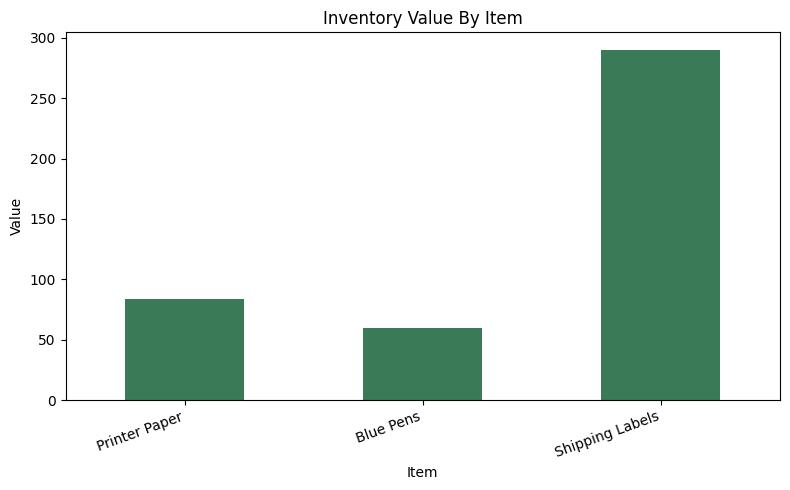

In [85]:
import matplotlib.pyplot as plt

chart_data = inventory.copy()
chart_data["market_value"] = chart_data["market_value"].astype(float)

ax = chart_data.plot(
    kind="bar",
    x="name",
    y="market_value",
    legend=False,
    figsize=(8, 5),
    color="#3a7a57"
)
ax.set_title("Inventory Value By Item")
ax.set_xlabel("Item")
ax.set_ylabel("Value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 13. What To Do Next

At this point you have seen the full flow:

1. Create an inventory.
2. Use that inventory as the active working context.
3. Inspect the default fields.
4. Add custom fields.
5. Add items.
6. Review summaries and reports.

That is the foundation of the current generic inventory system.